# Iris flowers Classification 

## 1️. Required Libraries 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 2. Read Dataset

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

### 📊 Dataset Overview

The **Iris dataset** is one of the most famous datasets in the world of Machine Learning. It contains **150 samples** of three different species of Iris flowers, with 50 samples for each species. The goal is to classify the species of the flower based on the measurements of its leaves.

#### 🌸 Species:
1.  **Setosa**
2.  **Versicolor**
3.  **Virginica**



---

### 🔍 Attributes & Features

The dataset consists of **4 numeric features** (Inputs) and one target column (Output):

| Feature | Description |
| :--- | :--- |
| **Sepal Length** | Length of the sepal (in cm) |
| **Sepal Width** | Width of the sepal (in cm) |
| **Petal Length** | Length of the petal (in cm) |
| **Petal Width** | Width of the petal (in cm) |
| **Species** | The target class (The type of flower) |

**Note:** The **Sepal** is the outer green leaf that protects the flower bud, while the **Petal** is the inner colored leaf of the flower.

## 3️. Exploratory Data Analysis (EDA)

### Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### Description

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


### Target Column

In [11]:
print(df['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [12]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

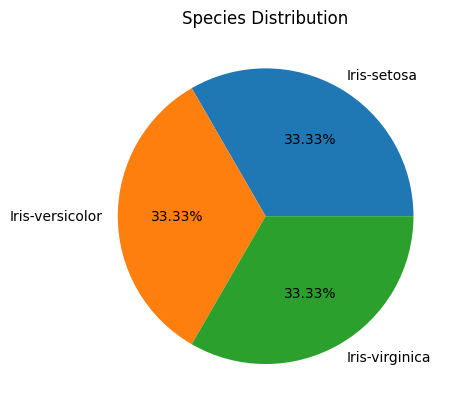

In [13]:
plt.pie(
    x=df['Species'].value_counts().values,
    labels=df['Species'].value_counts().index,
    autopct='%.2f%%'
)
plt.title("Species Distribution")
plt.show()

In [14]:
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

### Removing unnecessary columns

In [15]:
df.drop(columns=['Id'], inplace=True)

In [16]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Missing Values

In [17]:
df.isna().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### Duplication Values

In [18]:
df.duplicated().sum()

3

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

0

## Correlation Heatmap

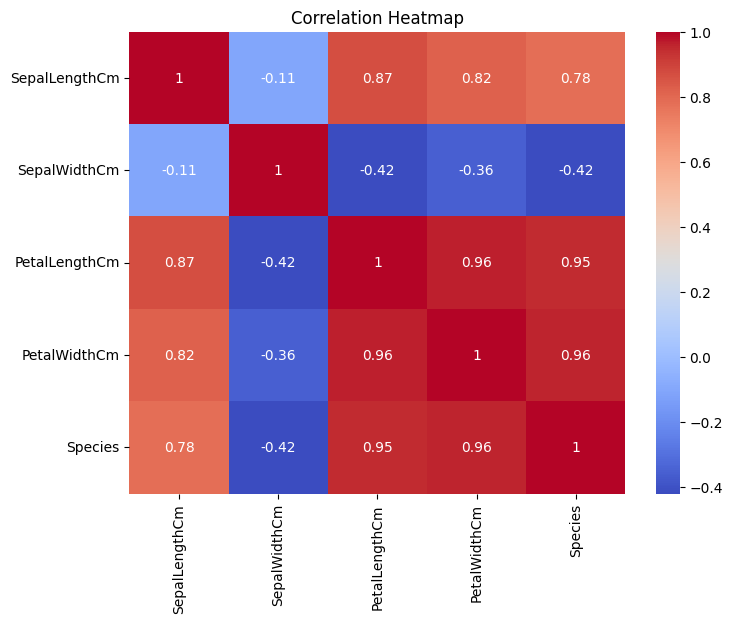

In [21]:
num_col = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(8,6))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 4️. Split Data into Features and Target

In [22]:
X = df.drop(columns=['Species'])
y = df['Species']

In [23]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Train-Test Split

In [25]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.2 ,  random_state=42)

In [26]:
X_test.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
127,6.1,3.0,4.9,1.8
53,5.5,2.3,4.0,1.3
140,6.7,3.1,5.6,2.4
19,5.1,3.8,1.5,0.3
106,4.9,2.5,4.5,1.7


## 6️. Modeling 

In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=1.0)

In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print(f"Cross-Validation Accuracy: {np.mean(cv_scores):.2f} (+/- {np.std(cv_scores):.2f})")

Cross-Validation Accuracy: 0.97 (+/- 0.02)


In [29]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print(f"Logistic Regression - Cross-Validation Accuracy: {np.mean(cv_scores):.2f}")
print(f"Logistic Regression - Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Logistic Regression - Cross-Validation Accuracy: 0.97
Logistic Regression - Test Accuracy: 0.93


In [31]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



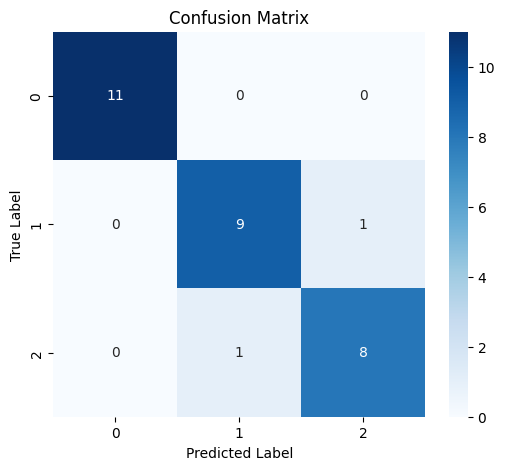

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()